In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import h5py
from astropy import units as u 
import agama
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{txfonts}",
})

In [2]:
path = "/Users/ferrone/repos/bar-dynamics/simulations/"
fname = "pal5_bar_pattern_speed_v1__mw-fiducial_v1__lookback-4gyr__n-512__seed-0042__75958ac3.h5"
myfile = h5py.File(path+fname,mode="r")
mykeys = list(myfile['runs'].keys())
# pick a key 
key_index = 16+1
barpatternspeed=myfile['runs'][mykeys[key_index]].attrs['bar_pattern_speed_magnitude_kms_kpc']
print(barpatternspeed)

33.0


In [3]:
# extract the data
x=myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][:,0]
y=myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][:,1]
z=myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][:,2]
R = np.sqrt(x**2 + y**2)
theta = np.arctan2(y,x)
nt = len(R)
# convert gyr to integration units 
t0=-myfile.attrs['lookback_gyr']*u.Gyr
unitT=u.s * (u.kpc/u.km)
timestamps=np.linspace(0,t0.to(unitT).value,nt)

[None, Text(0.5, 1.0, 'omega=33.00')]

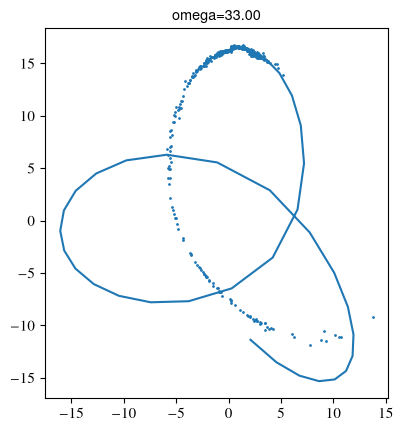

In [4]:
xp=myfile['runs'][mykeys[key_index]]['stream_phase_space'][:,1]
yp=myfile['runs'][mykeys[key_index]]['stream_phase_space'][:,2]
fig,axis=plt.subplots(1,1)
ll=34
axis.plot(y[-ll:],z[-ll:]);
axis.scatter(xp,yp,s=1)
axis.set(aspect="equal", title="omega={:.2f}".format(barpatternspeed))

## Action-angle frequency analysis

Rebuild the static axisymmetric + azimuthally-averaged-bar background from the metadata embedded in this run's HDF5 file (so it's guaranteed consistent with what generated the orbit), then use Agama's Staeckel-fudge `ActionFinder` to get $(J_r, J_z, J_\phi)$ and $(\Omega_r, \Omega_z, \Omega_\phi)$ along the progenitor orbit.

In [5]:
import configparser

agama.setUnits(length=1, velocity=1, mass=1)  # kpc, km/s, Msun -> matches the units used to generate this file

def build_axisymmetric_potential(config_text):
    """Rebuild the static disk+halo+azimuthally-averaged-bar background from the run's embedded config."""
    config = configparser.ConfigParser()
    config.read_string(config_text)

    def component(section, fields):
        return {
            key: config.get(section, value) if key == "type" else config.getfloat(section, value)
            for key, value in fields.items()
        }

    disk_thin = agama.Potential(**component("disk_thin", {
        "type": "type", "mass": "mass_msun", "scaleRadius": "scale_radius_kpc",
        "scaleHeight": "scale_height_kpc",
    }))
    disk_thick = agama.Potential(**component("disk_thick", {
        "type": "type", "mass": "mass_msun", "scaleRadius": "scale_radius_kpc",
        "scaleHeight": "scale_height_kpc",
    }))
    halo = agama.Potential(**component("halo", {
        "type": "type", "mass": "mass_msun", "scaleRadius": "scale_radius_kpc",
    }))
    axisymmetric = agama.Potential(disk_thin, disk_thick, halo)

    bar = agama.Potential(**component("bar", {
        "type": "type", "mass": "mass_msun", "scaleRadius": "scale_radius_kpc",
        "axisRatioY": "axis_ratio_y", "axisRatioZ": "axis_ratio_z",
    }))
    bar_axisymmetric = agama.Potential(
        type="CylSpline", potential=bar, mmax=0, gridsizeR=30, gridsizez=32,
        Rmin=0.1, Rmax=40, zmin=0.05, zmax=20,
    )
    return agama.Potential(axisymmetric, bar_axisymmetric)

tidal_potential = build_axisymmetric_potential(myfile.attrs["experiment_config_ini"])

In [6]:
# get the actions of the axis-symmetric case for comparison 
run_group = myfile['runs'][mykeys[0]]
orbit = run_group['progenitor_orbit_phase_space'][:]
action_finder_axissym = agama.ActionFinder(tidal_potential, interp=True)
actions_axissym, angles_axissym, freqs_axissym = action_finder_axissym(orbit, angles=True, frequencies=True)
# Agama's convention: columns are ordered (r, z, phi)

In [7]:
diffs = np.zeros((len(mykeys)-1,nt,))
patternspeeds = np.zeros((len(mykeys)-1,))
for key_index in range(1,len(mykeys)):
    run_group = myfile['runs'][mykeys[key_index]]
    orbit = run_group['progenitor_orbit_phase_space'][:]
    omega_bar = run_group.attrs['bar_pattern_speed_magnitude_kms_kpc']
    action_finder = agama.ActionFinder(tidal_potential, interp=True)
    actions, angles, freqs = action_finder(orbit, angles=True, frequencies=True)
    # get the RMS
    # diff=(actions-actions_axissym.mean(axis=0))
    diff=(actions-actions_axissym)
    diffs[key_index-1] = np.cumsum(np.sum(diff,axis=1))
    patternspeeds[key_index-1]=omega_bar


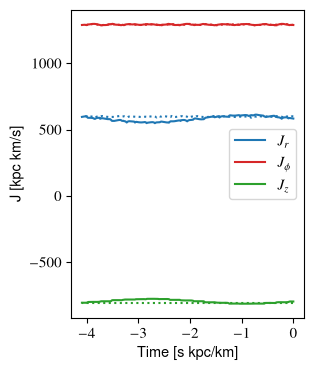

In [8]:
fig, axes = plt.subplots(1, figsize=(3, 4))
# for  J, label in zip([Jr, Jz, Jphi], [r"$J_r$", r"$J_z$", r"$J_\phi$"]):

axes.plot(timestamps, actions_axissym[:,0], linestyle =":", label=None,color="tab:blue")
axes.plot(timestamps, actions[:,0], linestyle ="-", label=r"$J_r$",color="tab:blue")

axes.plot(timestamps, actions_axissym[:,1], linestyle =":", label=None,color="tab:red")
axes.plot(timestamps, actions[:,1], linestyle ="-", label=r"$J_\phi$",color="tab:red")

axes.plot(timestamps, actions_axissym[:,2], linestyle =":", label=None,color="tab:green")
axes.plot(timestamps, actions[:,2], linestyle ="-", label=r"$J_z$",color="tab:green")

# for  J, label in zip([Jr_axissym, Jz_axissym, Jphi_axissym], [r"$J_r!$", r"$J_z!$", r"$J_\phi!$"]):
    # axes.plot(timestamps, J,label=label)

axes.legend()
axes.set(xlabel="Time [s kpc/km]",ylabel="J [kpc km/s]");

In [9]:
import sys
sys.path.append("../analysis/")
import plot_types
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
vmin = patternspeeds.min()
vmax = patternspeeds.max()
CMAP = plt.get_cmap("rainbow")
NORM = Normalize(vmin=vmin, vmax=vmax)

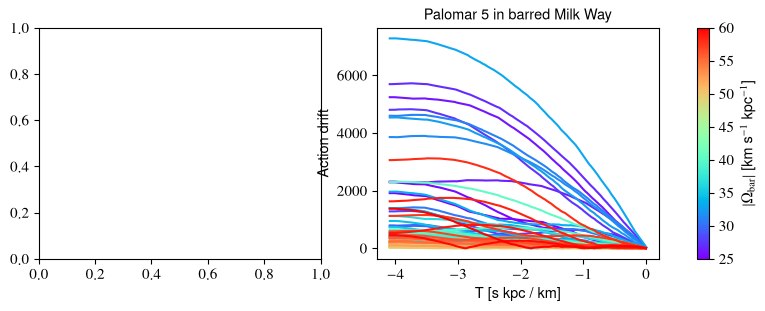

In [15]:
# look at all of the action drift 
fig,axis=plt.subplots(1,2,figsize=(10,3))
for i in range(len(mykeys)-1):
    axis[1].plot(timestamps,np.abs(diffs[i,:]),color=CMAP(NORM(patternspeeds[i])))

axis[1].set(ylabel="Action drift", xlabel="T [s kpc / km]", title="Palomar 5 in barred Milk Way")
colorbar = fig.colorbar(
    ScalarMappable(norm=NORM, cmap=CMAP),
        ax=axis,
        label=r"$|\Omega_\mathrm{bar}|$ [km s$^{-1}$ kpc$^{-1}$]",
    )

In [11]:
# lemme pick out one of the worst ones? 
nmax=6
biggest_changes=np.argsort(np.abs(diffs[:,-1]))[::-1][0:nmax]
least_changes=np.argsort(np.abs(diffs[:,-1]))[0:nmax]

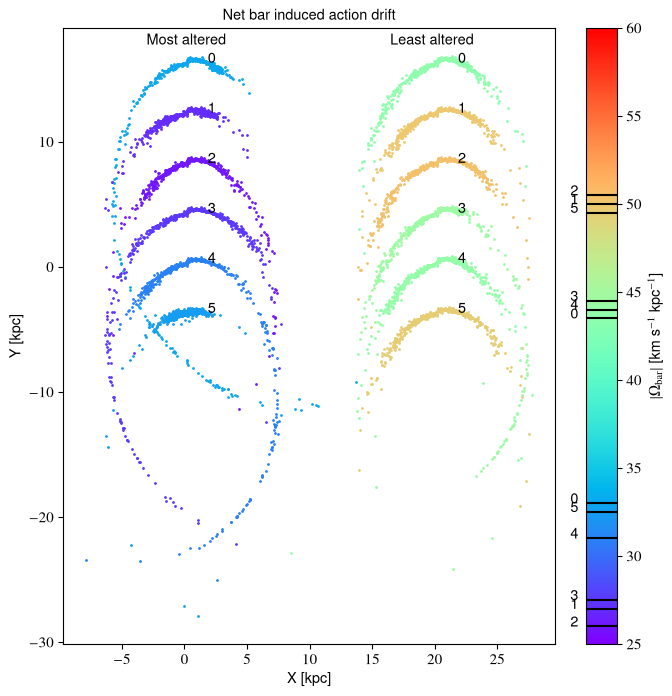

In [12]:
# lets plot the top three? 
fig,axis=plt.subplots(1,1,figsize=(8,8))
y_offset = 4
x_offset = 20
for i in range(nmax):
    key_index = biggest_changes[i]+1
    xpos = myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][-1,1]
    ypos = myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][-1,2]
    xp=myfile['runs'][mykeys[key_index]]['stream_phase_space'][:,1]
    yp=myfile['runs'][mykeys[key_index]]['stream_phase_space'][:,2]
    axis.scatter(xp,yp-i*y_offset,s=1,color=CMAP(NORM(patternspeeds[key_index-1])))
    axis.text(xpos,ypos-i*y_offset,s="{:d}".format(i))

for i in range(nmax):
    key_index = least_changes[i]+1
    xpos = myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][-1,1]
    ypos = myfile['runs'][mykeys[key_index]]['progenitor_orbit_phase_space'][-1,2]
    xp=myfile['runs'][mykeys[key_index]]['stream_phase_space'][:,1]
    yp=myfile['runs'][mykeys[key_index]]['stream_phase_space'][:,2]
    axis.scatter(xp+x_offset,yp-i*y_offset,s=1,color=CMAP(NORM(patternspeeds[key_index-1])))
    axis.text(xpos+x_offset,ypos-i*y_offset,s="{:d}".format(i))


    
axis.set(aspect="equal",title="Net bar induced action drift")
axis.text(0.25,0.99,s="Most altered",transform=axis.transAxes,ha="center",va="top")
axis.text(0.75,0.99,s="Least altered",transform=axis.transAxes,ha="center",va="top")
colorbar = fig.colorbar(
    ScalarMappable(norm=NORM, cmap=CMAP),
        ax=axis,
        label=r"$|\Omega_\mathrm{bar}|$ [km s$^{-1}$ kpc$^{-1}$]",
    )

for i in range(nmax):
    key_index = biggest_changes[i]+1
    colorbar.ax.axhline(patternspeeds[key_index-1], color="black", linewidth=1.5, zorder=10)
    colorbar.ax.text(-.5, patternspeeds[key_index-1], s="{:d}".format(i))

for i in range(nmax):
    key_index = least_changes[i]+1
    colorbar.ax.axhline(patternspeeds[key_index-1], color="black", linewidth=1.5, zorder=10)
    colorbar.ax.text(-.5, patternspeeds[key_index-1], s="{:d}".format(i))

axis.set(xlabel="X [kpc]", ylabel="Y [kpc]");